## 🏗️ Cell 13 — Build U-Net Segmentation Model

In [ ]:
def build_unet(input_size=(224, 224, 3)):
    """U-Net with skip connections for burnt area segmentation"""
    inp = keras.Input(input_size)

    # ── Encoder ──
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        return x

    c1 = conv_block(inp, 64);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1,  128); p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2,  256); p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3,  512); p4 = layers.MaxPooling2D()(c4)

    # ── Bottleneck ──
    bn = conv_block(p4, 1024)

    # ── Decoder ──
    def up_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
        return x

    u4 = up_block(bn, c4, 512)
    u3 = up_block(u4, c3, 256)
    u2 = up_block(u3, c2, 128)
    u1 = up_block(u2, c1,  64)

    out = layers.Conv2D(1, 1, activation='sigmoid', name='seg_output')(u1)
    return keras.Model(inp, out, name='UNet')

# Input to U-Net uses [0,1] normalized images (not EfficientNet's [-1,1])
unet_model = build_unet()

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2.*intersection+smooth) / (tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+smooth)

def combined_loss(y_true, y_pred):
    return 0.5*keras.losses.binary_crossentropy(y_true, y_pred) + 0.5*dice_loss(y_true, y_pred)

unet_model.compile(
    optimizer=Adam(1e-3),
    loss=combined_loss,
    metrics=['accuracy']
)
print(f'✅ U-Net built: {unet_model.count_params():,} params')

✅ U-Net built: 31,055,297 params


## 🎭 Cell 14 — Create HSV Segmentation Masks + Train U-Net

Building HSV segmentation dataset (up to 1000 images)...


100%|██████████| 1000/1000 [00:04<00:00, 210.92it/s]



Dataset: (1000, 224, 224, 3)  masks: (1000, 224, 224, 1)
Images with detected fire/burn: 901/1000 (90.1%)
Average mask coverage: 19.8%
Train:680  Val:120  Test:200


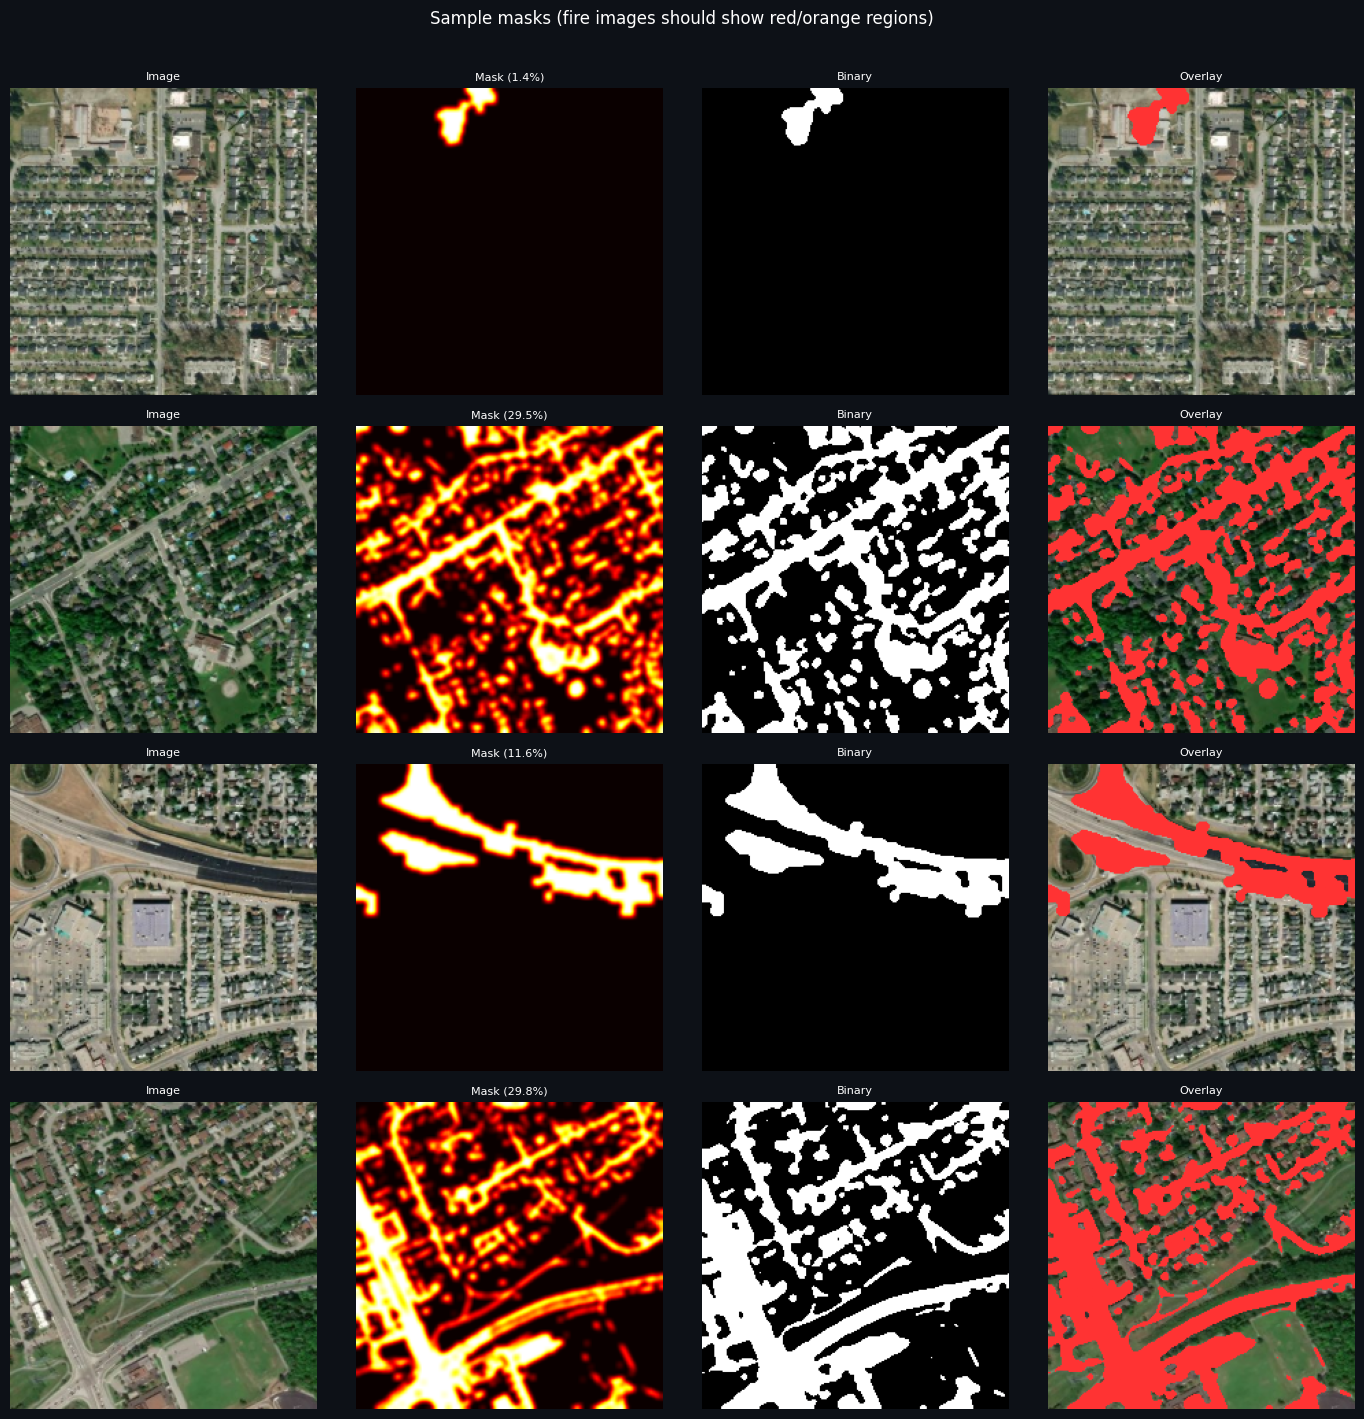


🚀 Training U-Net...
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3510 - loss: 0.6872   
Epoch 1: val_loss improved from None to 33.52347, saving model to /content/best_unet.keras

Epoch 1: finished saving model to /content/best_unet.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.3856 - loss: 0.6502 - val_accuracy: 0.0482 - val_loss: 33.5235 - learning_rate: 0.0010
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.4215 - loss: 0.5855
Epoch 2: val_loss improved from 33.52347 to 4.77978, saving model to /content/best_unet.keras

Epoch 2: finished saving model to /content/best_unet.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 866ms/step - accuracy: 0.4396 - loss: 0.5791 - val_accuracy: 0.0986 - val_loss: 4.7798 - learning_rate: 0.0010
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.4537 - loss: 0.5474
Epoch 3: val_loss improved from 4.77978 to 0.70967, saving model to /content/best_unet.keras

Epoch 3: finished saving model to /cont

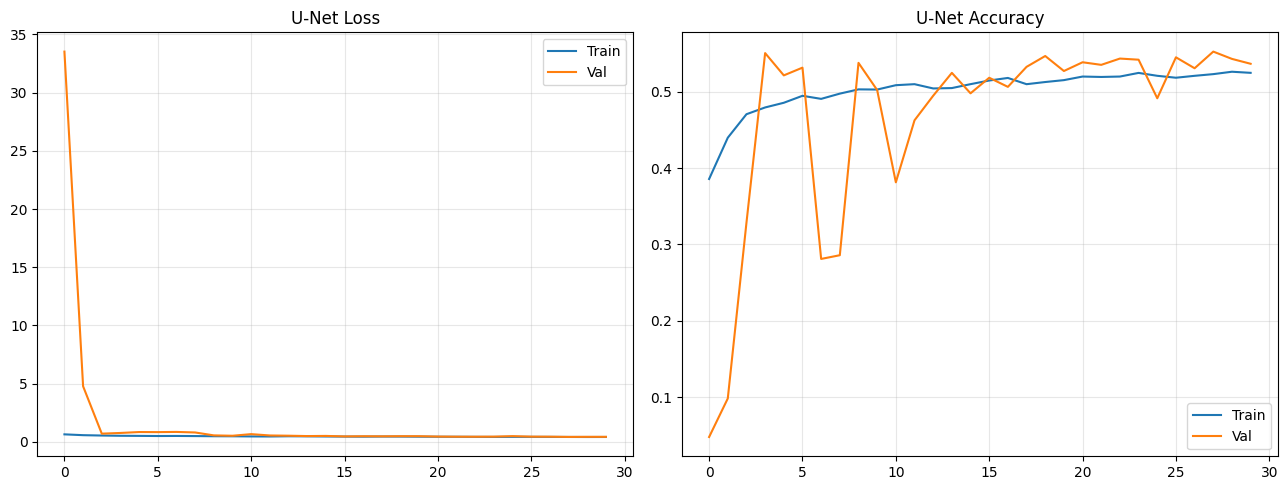

In [ ]:
# ════════════════════════════════════════════════════════════════
# FIX: HSV colour-detection masks (NOT synthetic circles)
# For fire images: detect red/orange flame + dark char regions
# For non-fire: all-zero mask (correct ground truth)
# ════════════════════════════════════════════════════════════════

def create_hsv_mask(path, is_fire):
    img  = cv2.imread(path)
    if img is None:
        return np.zeros((*IMG_SIZE,), dtype=np.float32)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, IMG_SIZE)
    hsv  = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    mask = np.zeros(IMG_SIZE, dtype=np.uint8)

    if is_fire:
        # Active flame: red-orange, high saturation & value
        m1 = cv2.inRange(hsv, np.array([0, 50,150]), np.array([15,255,255]))
        m2 = cv2.inRange(hsv, np.array([15,50,150]), np.array([30,255,255]))
        # Charred/burnt: very dark, low saturation
        m3 = cv2.inRange(hsv, np.array([0,  0,  0]), np.array([180,50, 80]))
        combined = cv2.bitwise_or(cv2.bitwise_or(m1, m2), m3)

        # Morphological cleanup
        k = np.ones((5,5), np.uint8)
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k)
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,  k)

        # Remove tiny noise blobs
        cnts, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in cnts:
            if cv2.contourArea(cnt) < 150:
                cv2.drawContours(combined, [cnt], -1, 0, -1)

        # Fallback: if colour detection finds nothing, use top-30% brightest
        if combined.mean() < 3:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            thr  = int(np.percentile(gray, 70))
            _, combined = cv2.threshold(gray, thr, 255, cv2.THRESH_BINARY)

        mask = combined

    mask_f = mask.astype(np.float32) / 255.0
    if mask_f.max() > 0:
        mask_f = cv2.GaussianBlur(mask_f, (7,7), 2)
        mask_f = np.clip(mask_f / mask_f.max(), 0, 1)
    return mask_f

def path_is_fire(path):
    folder = os.path.basename(os.path.dirname(path)).lower()
    return any(x in folder for x in ['fire','burn','wildfire','blaze','flame'])

print('Building HSV segmentation dataset (up to 1000 images)...')
seg_paths = all_paths[:min(1000, len(all_paths))]

X_seg, y_seg = [], []
n_fire_detected = 0
for path in tqdm(seg_paths):
    is_fire = path_is_fire(path)
    img = cv2.imread(path)
    if img is None: continue
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, IMG_SIZE).astype(np.float32) / 255.0  # [0,1] for U-Net
    mask = create_hsv_mask(path, is_fire)
    X_seg.append(img)
    y_seg.append(mask)
    if mask.mean() > 0.02:
        n_fire_detected += 1

X_seg = np.array(X_seg, dtype=np.float32)
y_seg = np.expand_dims(np.array(y_seg, dtype=np.float32), -1)

print(f'\nDataset: {X_seg.shape}  masks: {y_seg.shape}')
print(f'Images with detected fire/burn: {n_fire_detected}/{len(X_seg)} '
      f'({n_fire_detected/len(X_seg)*100:.1f}%)')
print(f'Average mask coverage: {y_seg.mean()*100:.1f}%')

Xtr,Xte,ytr,yte = train_test_split(X_seg, y_seg, test_size=0.2,  random_state=42)
Xtr,Xv, ytr,yv  = train_test_split(Xtr,   ytr,   test_size=0.15, random_state=42)
print(f'Train:{len(Xtr)}  Val:{len(Xv)}  Test:{len(Xte)}')

# ── visualise a few masks before training ──
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Sample masks (fire images should show red/orange regions)',
             color='white', fontsize=12, y=1.01)
for i in range(4):
    idx = np.random.randint(len(Xtr))
    axes[i,0].imshow(Xtr[idx]); axes[i,0].set_title('Image', color='w', fontsize=8); axes[i,0].axis('off')
    axes[i,1].imshow(ytr[idx,:,:,0], cmap='hot', vmin=0, vmax=1)
    axes[i,1].set_title(f'Mask ({ytr[idx].mean()*100:.1f}%)', color='w', fontsize=8); axes[i,1].axis('off')
    binary = (ytr[idx,:,:,0]>0.3).astype(float)
    axes[i,2].imshow(binary, cmap='gray'); axes[i,2].set_title('Binary', color='w', fontsize=8); axes[i,2].axis('off')
    ov = Xtr[idx].copy(); ov[binary>0.5] = [1,0.2,0.2]
    axes[i,3].imshow(ov); axes[i,3].set_title('Overlay', color='w', fontsize=8); axes[i,3].axis('off')
plt.tight_layout(); plt.savefig('/content/mask_samples.png', dpi=120, facecolor='#0d1117'); plt.show()

# ── train U-Net ──
print('\n🚀 Training U-Net...')
unet_cb = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_unet.keras',
                    monitor='val_loss', save_best_only=True, verbose=1)
]

h_unet = unet_model.fit(
    Xtr, ytr,
    validation_data=(Xv, yv),
    epochs=30, batch_size=16,
    callbacks=unet_cb, verbose=1
)
unet_model.save('/content/unet_final.keras')
print('✅ U-Net training complete!')

fig,(a1,a2) = plt.subplots(1,2,figsize=(13,5))
a1.plot(h_unet.history['loss'],     label='Train'); a1.plot(h_unet.history['val_loss'], label='Val')
a1.set_title('U-Net Loss'); a1.legend(); a1.grid(True, alpha=0.3)
a2.plot(h_unet.history['accuracy'], label='Train'); a2.plot(h_unet.history['val_accuracy'], label='Val')
a2.set_title('U-Net Accuracy'); a2.legend(); a2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('/content/unet_training.png', dpi=150); plt.show()

## 🧪 Cell 15 — Test U-Net Segmentation Results

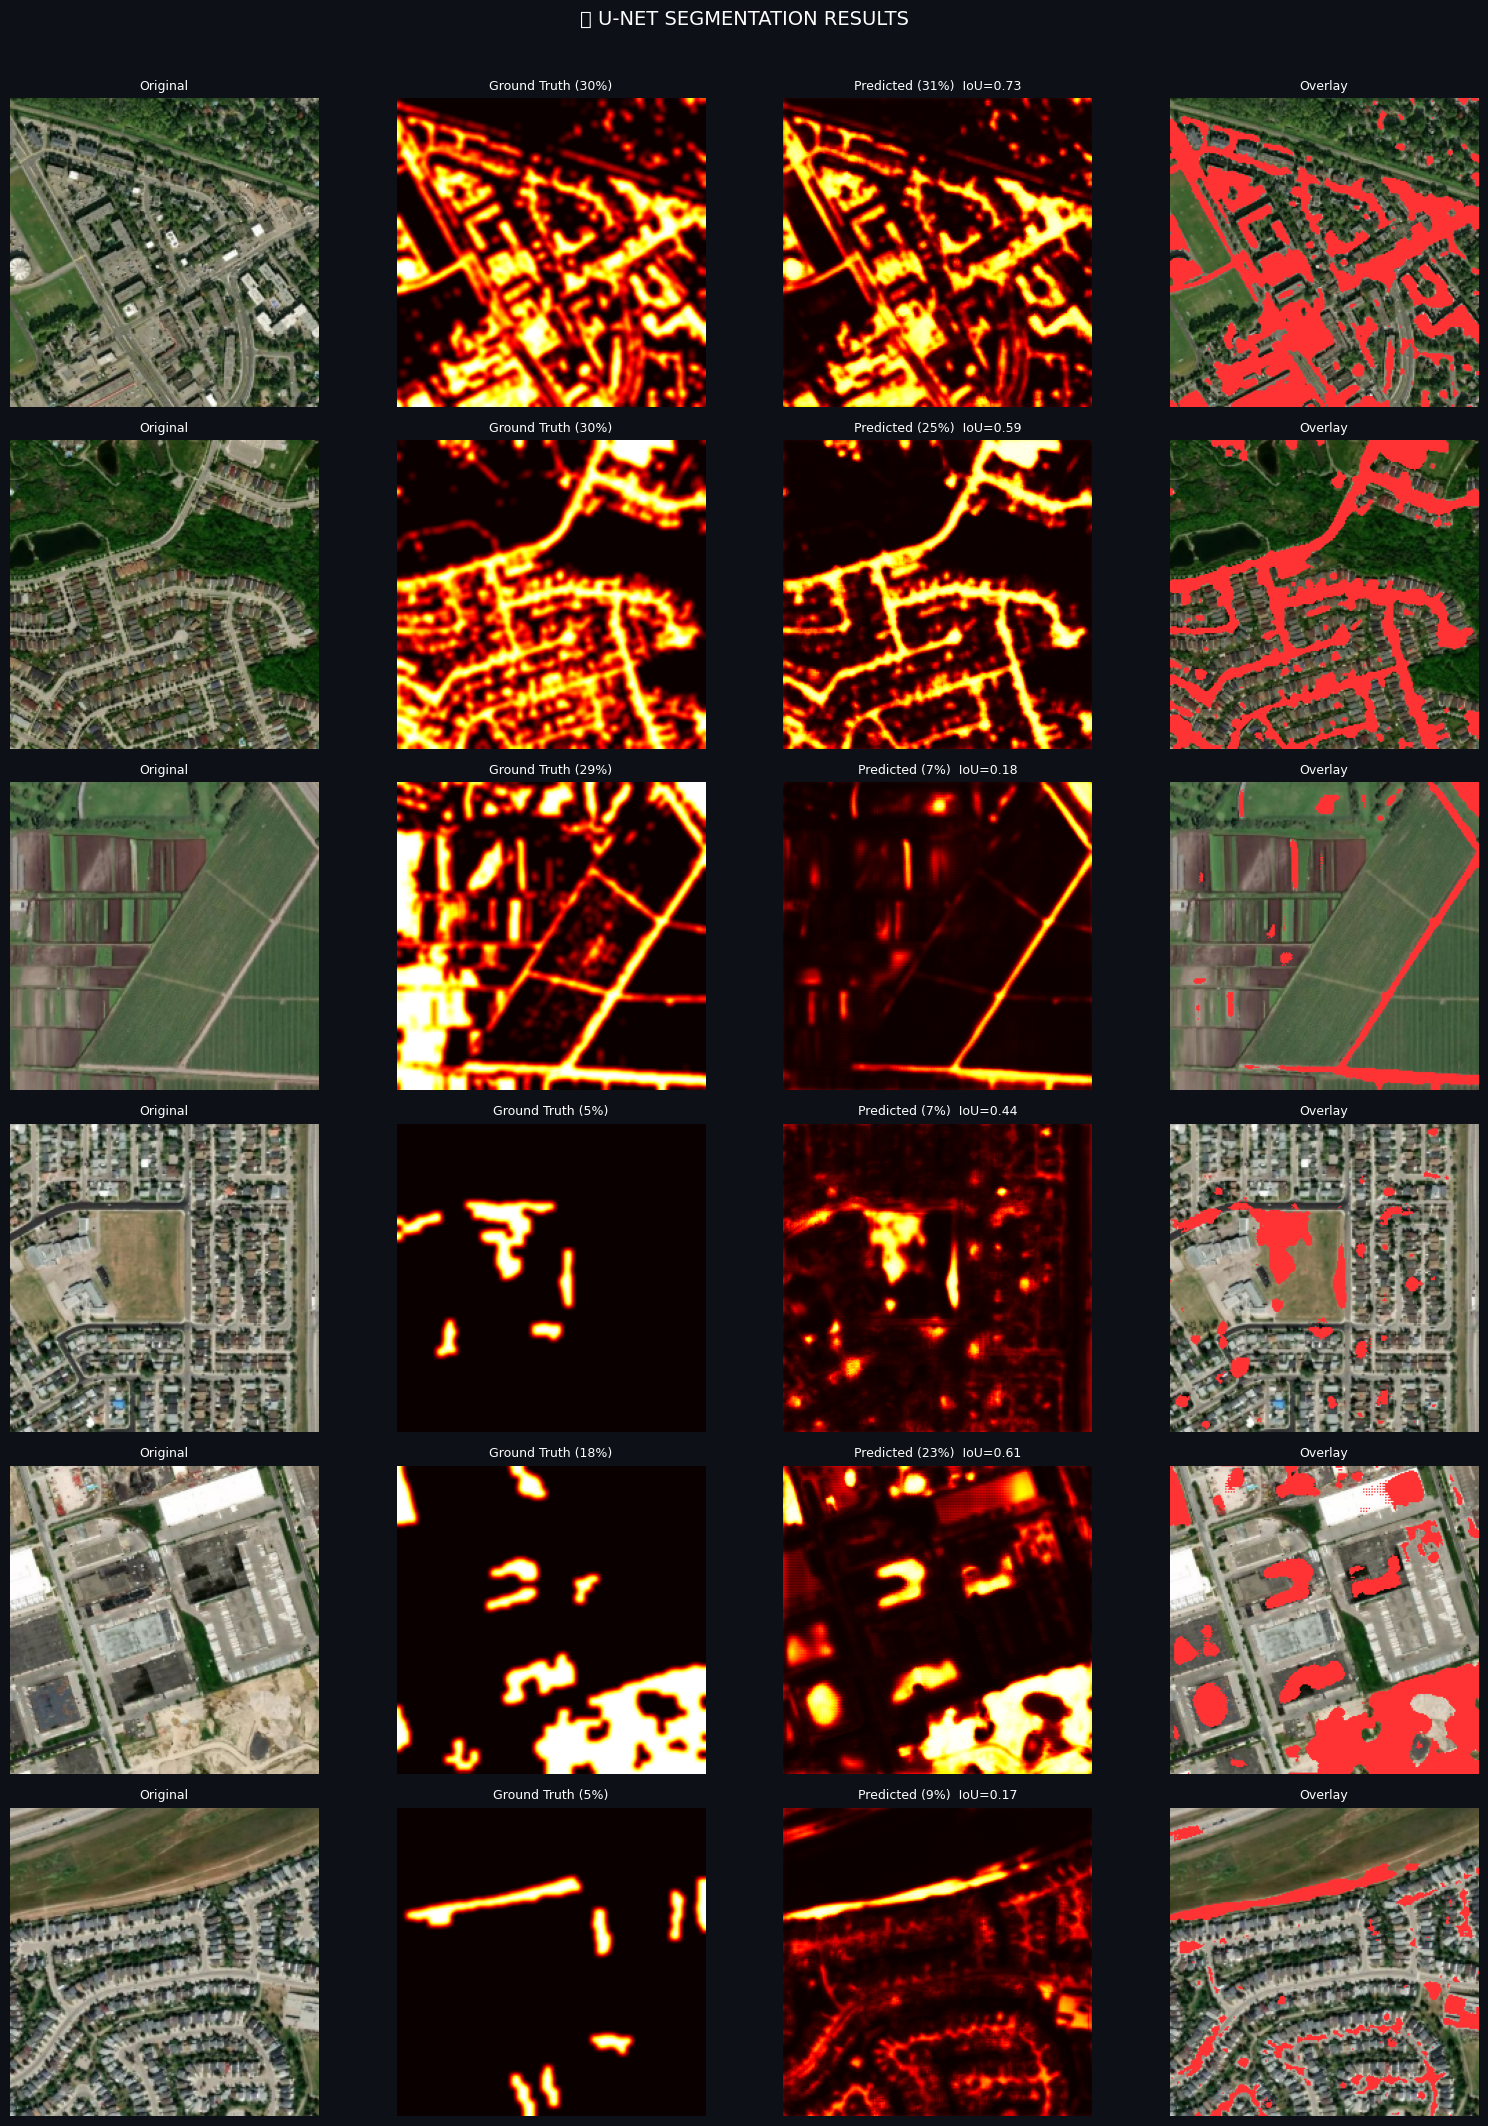

✅ U-Net test complete


In [ ]:
unet_model = keras.models.load_model('/content/best_unet.keras',
                                     custom_objects={'combined_loss': combined_loss})

n   = min(6, len(Xte))
idx = np.random.choice(len(Xte), n, replace=False)
fig, axes = plt.subplots(n, 4, figsize=(16, n*3.5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🔥 U-NET SEGMENTATION RESULTS', color='white', fontsize=14, y=1.01)
if n==1: axes=[axes]

for i, si in enumerate(idx):
    img       = Xte[si]
    true_mask = yte[si,:,:,0]
    pred_mask = unet_model.predict(img[np.newaxis], verbose=0)[0,:,:,0]
    binary    = (pred_mask > 0.3).astype(float)
    iou = (np.sum((binary>0.5)&(true_mask>0.3)) /
           (np.sum((binary>0.5)|(true_mask>0.3))+1e-6))

    axes[i][0].imshow(img); axes[i][0].set_title('Original', color='w', fontsize=9); axes[i][0].axis('off')
    axes[i][1].imshow(true_mask, cmap='hot', vmin=0, vmax=1)
    axes[i][1].set_title(f'Ground Truth ({true_mask.mean()*100:.0f}%)', color='w', fontsize=9); axes[i][1].axis('off')
    axes[i][2].imshow(pred_mask, cmap='hot', vmin=0, vmax=1)
    axes[i][2].set_title(f'Predicted ({binary.mean()*100:.0f}%)  IoU={iou:.2f}', color='w', fontsize=9); axes[i][2].axis('off')
    ov = img.copy(); ov[binary>0.5] = [1, 0.2, 0.2]
    axes[i][3].imshow(ov); axes[i][3].set_title('Overlay', color='w', fontsize=9); axes[i][3].axis('off')

plt.tight_layout()
plt.savefig('/content/unet_results.png', dpi=150, facecolor='#0d1117')
plt.show()
print('✅ U-Net test complete')

## 🖥️ Cell 16 — Full Analysis Pipeline

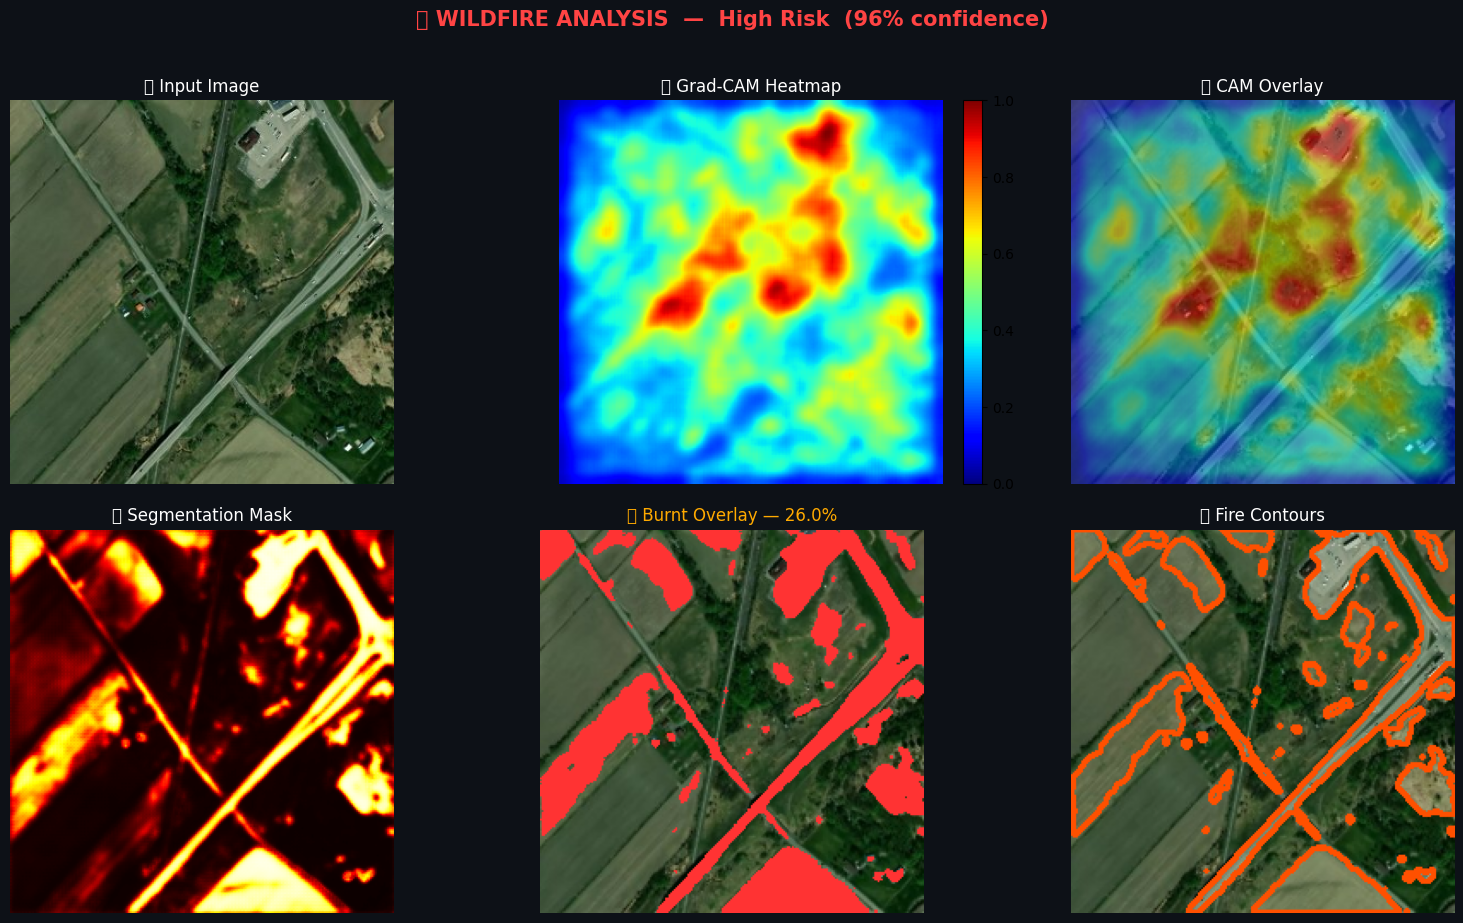


📊 Results:
   risk_level     : High Risk
   class_name     : wildfire
   confidence     : 95.6%
   burnt_area     : 26.0%
   severity       : MODERATE
   severity_color : #ffaa00
   num_regions    : 45

✅ Analysis pipeline ready!


In [ ]:
def analyze_image(img_rgb_uint8):
    """
    Full pipeline for a single image.
    img_rgb_uint8 : numpy (H, W, 3) uint8 RGB
    Returns: dict with all results + matplotlib figure
    """
    # ── preprocess ──
    img_r  = cv2.resize(img_rgb_uint8, IMG_SIZE)
    inp_e  = ((img_r.astype(np.float32)/127.5) - 1.0)  # classifier input
    inp_u  = img_r.astype(np.float32) / 255.0           # U-Net input

    # ── classification ──
    probs  = best_model.predict(inp_e[np.newaxis], verbose=0)[0]
    ci     = int(np.argmax(probs))
    conf   = float(probs[ci])
    name   = CLASS_NAMES[ci]
    risk   = RISK_MAP[name]

    # ── Grad-CAM ──
    hmap, _ = get_gradcam(best_model, inp_e, ci)
    overlay = apply_colormap_overlay(img_r, hmap)

    # ── segmentation ──
    seg    = unet_model.predict(inp_u[np.newaxis], verbose=0)[0,:,:,0]
    binary = (seg > 0.3).astype(np.float32)
    burnt_pct = float(binary.mean() * 100)

    # ── severity ──
    if   burnt_pct > 50: sev='CRITICAL'; sc='#ff0000'
    elif burnt_pct > 30: sev='SEVERE';   sc='#ff6600'
    elif burnt_pct > 15: sev='MODERATE'; sc='#ffaa00'
    elif burnt_pct >  5: sev='MILD';     sc='#aaff00'
    else:                sev='MINIMAL';  sc='#00ff88'

    # ── fire contours ──
    seg_u8   = (seg*255).astype(np.uint8)
    _, thr   = cv2.threshold(seg_u8, 76, 255, cv2.THRESH_BINARY)
    cnts, _  = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_img = img_r.copy()
    cv2.drawContours(contour_img, cnts, -1, (255, 80, 0), 2)

    # ── figure ──
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.patch.set_facecolor('#0d1117')
    rc = '#ff4444' if risk=='High Risk' else '#44ff44'
    fig.suptitle(f'🔥 WILDFIRE ANALYSIS  —  {risk}  ({conf:.0%} confidence)',
                 color=rc, fontsize=15, fontweight='bold', y=1.02)

    axes[0,0].imshow(img_rgb_uint8); axes[0,0].set_title('📸 Input Image', color='w'); axes[0,0].axis('off')
    im=axes[0,1].imshow(hmap,cmap='jet',vmin=0,vmax=1); axes[0,1].set_title('🔍 Grad-CAM Heatmap', color='w'); axes[0,1].axis('off')
    plt.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.04)
    axes[0,2].imshow(overlay); axes[0,2].set_title('🎯 CAM Overlay', color='w'); axes[0,2].axis('off')
    axes[1,0].imshow(seg, cmap='hot', vmin=0, vmax=1); axes[1,0].set_title('🔥 Segmentation Mask', color='w'); axes[1,0].axis('off')
    ov2 = inp_u.copy(); ov2[binary>0.5]=[1,0.2,0.2]
    axes[1,1].imshow(ov2); axes[1,1].set_title(f'🔴 Burnt Overlay — {burnt_pct:.1f}%', color=sc); axes[1,1].axis('off')
    axes[1,2].imshow(contour_img); axes[1,2].set_title('🗺️ Fire Contours', color='w'); axes[1,2].axis('off')

    for ax in axes.flat:
        ax.set_facecolor('#0d1117')

    plt.tight_layout()

    return fig, {
        'risk_level'   : risk,
        'class_name'   : name,
        'confidence'   : f'{conf*100:.1f}%',
        'burnt_area'   : f'{burnt_pct:.1f}%',
        'severity'     : sev,
        'severity_color': sc,
        'num_regions'  : len(cnts)
    }

# ── quick test ──
test_path = p_test[np.random.randint(len(p_test))]
img = cv2.imread(test_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
fig, results = analyze_image(img)
plt.savefig('/content/analysis_test.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n📊 Results:')
for k,v in results.items():
    print(f'   {k:15s}: {v}')
print('\n✅ Analysis pipeline ready!')

## 🎨 Cell 17 — Launch Gradio UI

In [ ]:
!pip install -q gradio plotly

import gradio as gr
import plotly.graph_objects as go
from datetime import datetime
import traceback, io as _io

# reload models to make sure fresh
best_model  = keras.models.load_model('/content/best_final.keras')
unet_model  = keras.models.load_model('/content/best_unet.keras',
                                      custom_objects={'combined_loss': combined_loss})

# ── plotly charts ──
def risk_gauge(conf, risk):
    fig = go.Figure(go.Indicator(
        mode='gauge+number',
        value=float(conf*100),
        title={'text':f'Risk: {risk}','font':{'color':'white','size':16}},
        number={'font':{'color':'white','size':26},'suffix':'%'},
        gauge={
            'axis':{'range':[0,100],'tickcolor':'white','tickfont':{'color':'white'}},
            'bar':{'color':'#ff4444' if risk=='High Risk' else '#44ff44'},
            'steps':[
                {'range':[0,40],'color':'rgba(46,204,113,0.3)'},
                {'range':[40,70],'color':'rgba(241,196,15,0.3)'},
                {'range':[70,100],'color':'rgba(231,76,60,0.3)'}
            ],
            'threshold':{'line':{'color':'white','width':3},
                         'thickness':0.75,'value':conf*100}
        }
    ))
    fig.update_layout(paper_bgcolor='rgba(0,0,0,0)',
                      plot_bgcolor='rgba(0,0,0,0)',
                      font_color='white', height=250,
                      margin=dict(l=30,r=30,t=50,b=20))
    return fig

def area_bar(burnt_pct):
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=['🔴 Burnt','🟢 Safe'],
        y=[float(burnt_pct), float(100-burnt_pct)],
        marker_color=['#ff4444','#44ff44'],
        text=[f'{burnt_pct:.1f}%',f'{100-burnt_pct:.1f}%'],
        textposition='outside', textfont={'color':'white','size':14}
    ))
    fig.update_layout(
        title={'text':'Area Distribution','font':{'color':'white','size':14}},
        paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(30,30,50,0.8)',
        font_color='white', showlegend=False, height=260,
        margin=dict(l=30,r=30,t=50,b=30),
        yaxis=dict(gridcolor='#444',range=[0,115]),
        xaxis=dict(gridcolor='#444')
    )
    return fig

def prob_bar(probs):
    fig = go.Figure()
    colors = ['#ff4444' if RISK_MAP.get(c,'Low Risk')=='High Risk' else '#44ff44'
              for c in CLASS_NAMES]
    fig.add_trace(go.Bar(
        x=CLASS_NAMES,
        y=[float(p*100) for p in probs],
        marker_color=colors,
        text=[f'{p*100:.1f}%' for p in probs],
        textposition='outside', textfont={'color':'white','size':11}
    ))
    fig.update_layout(
        title={'text':'Class Probabilities','font':{'color':'white','size':14}},
        paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(30,30,50,0.8)',
        font_color='white', showlegend=False, height=260,
        margin=dict(l=30,r=30,t=50,b=60),
        yaxis=dict(gridcolor='#444',range=[0,115]),
        xaxis=dict(tickangle=-30)
    )
    return fig

# ── main inference function ──
def analyze_ui(image):
    try:
        if image is None:
            return (None, None, None, None, None,
                    '❌ Please upload an image', None)

        img_uint8 = image.astype(np.uint8)

        # ── preprocess ──
        img_r = cv2.resize(img_uint8, IMG_SIZE)
        inp_e = ((img_r.astype(np.float32)/127.5) - 1.0)
        inp_u = img_r.astype(np.float32) / 255.0

        # ── classify ──
        probs = best_model.predict(inp_e[np.newaxis], verbose=0)[0]
        ci    = int(np.argmax(probs)); conf = float(probs[ci])
        name  = CLASS_NAMES[ci]; risk = RISK_MAP[name]

        # ── Grad-CAM ──
        hmap, _ = get_gradcam(best_model, inp_e, ci)
        cam_overlay = apply_colormap_overlay(img_r, hmap)

        # ── segmentation ──
        seg    = unet_model.predict(inp_u[np.newaxis], verbose=0)[0,:,:,0]
        binary = (seg > 0.3).astype(np.float32)
        burnt_pct = float(binary.mean() * 100)

        # ── severity ──
        if   burnt_pct > 50: sev='🔴 CRITICAL'
        elif burnt_pct > 30: sev='🟠 SEVERE'
        elif burnt_pct > 15: sev='🟡 MODERATE'
        elif burnt_pct >  5: sev='🟢 MILD'
        else:                sev='⚪ MINIMAL'

        # ── fire contours ──
        seg_u8  = (seg*255).astype(np.uint8)
        _, thr  = cv2.threshold(seg_u8, 76, 255, cv2.THRESH_BINARY)
        cnts, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_img = img_r.copy()
        cv2.drawContours(contour_img, cnts, -1, (255,80,0), 2)
        seg_overlay = inp_u.copy(); seg_overlay[binary>0.5] = [1,0.2,0.2]
        seg_overlay = (seg_overlay * 255).astype(np.uint8)

        # ── status HTML ──
        rc = '#ff4444' if risk=='High Risk' else '#44ff44'
        status_html = f"""
<div style="background:#111827;padding:20px;border-radius:12px;
            border:2px solid {rc};font-family:monospace">
  <h2 style="color:{rc};margin:0 0 12px">{risk}</h2>
  <table style="color:white;width:100%;border-collapse:collapse">
    <tr><td style="padding:6px;color:#aaa">Class</td>
        <td style="padding:6px;font-weight:bold">{name}</td></tr>
    <tr style="background:#1f2937">
        <td style="padding:6px;color:#aaa">Confidence</td>
        <td style="padding:6px;font-weight:bold">{conf*100:.1f}%</td></tr>
    <tr><td style="padding:6px;color:#aaa">Burnt Area</td>
        <td style="padding:6px;font-weight:bold">{burnt_pct:.1f}%</td></tr>
    <tr style="background:#1f2937">
        <td style="padding:6px;color:#aaa">Severity</td>
        <td style="padding:6px;font-weight:bold">{sev}</td></tr>
    <tr><td style="padding:6px;color:#aaa">Regions</td>
        <td style="padding:6px">{len(cnts)} detected</td></tr>
    <tr style="background:#1f2937">
        <td style="padding:6px;color:#aaa">Time</td>
        <td style="padding:6px">{datetime.now().strftime('%H:%M:%S')}</td></tr>
  </table>
</div>"""

        return (cam_overlay,
                seg_overlay,
                contour_img,
                risk_gauge(conf, risk),
                area_bar(burnt_pct),
                status_html,
                prob_bar(probs))

    except Exception as e:
        traceback.print_exc()
        return (None,None,None,None,None,
                f'<div style="color:red">❌ Error: {str(e)}</div>',None)

# ── Build UI ──
CSS = """
body, .gradio-container { background: #0d1117 !important; color: white !important; }
.gr-button-primary { background: linear-gradient(135deg,#ff4444,#ff8800) !important; border:none !important; font-weight:bold !important; }
h1,h2,h3 { color: #ff6b6b !important; }
"""

with gr.Blocks(css=CSS, title='🔥 Wildfire Intelligence System') as demo:

    gr.HTML("""
    <div style="text-align:center;padding:30px;background:linear-gradient(135deg,#1a0a0a,#0d1117);
                border-radius:16px;margin-bottom:20px;border:1px solid #ff444433">
      <h1 style="font-size:2.5em;margin:0;color:#ff6b6b">🔥 Wildfire Intelligence System</h1>
      <p style="color:#888;margin:8px 0 0">EfficientNetB0 + U-Net · Grad-CAM · Real-time Analysis</p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp_img  = gr.Image(label='📸 Upload Satellite Image', type='numpy',
                                height=300)
            btn      = gr.Button('🚀 Run Analysis', variant='primary', size='lg')
            status   = gr.HTML(value='<div style="color:#888;padding:10px">Ready</div>')

        with gr.Column(scale=2):
            with gr.Tabs():
                with gr.Tab('🎯 Grad-CAM'):
                    cam_out = gr.Image(label='Grad-CAM Overlay', height=300)
                with gr.Tab('🔥 Segmentation'):
                    seg_out = gr.Image(label='Burnt Area Overlay', height=300)
                with gr.Tab('🗺️ Contours'):
                    cnt_out = gr.Image(label='Fire Region Contours', height=300)

    with gr.Row():
        gauge_out = gr.Plot(label='Risk Gauge')
        area_out  = gr.Plot(label='Area Distribution')
        prob_out  = gr.Plot(label='Class Probabilities')

    btn.click(
        fn=analyze_ui,
        inputs=inp_img,
        outputs=[cam_out, seg_out, cnt_out,
                 gauge_out, area_out, status, prob_out]
    )

    gr.HTML('<hr style="border-color:#333;margin:20px 0">')
    gr.HTML('<p style="text-align:center;color:#555;font-size:0.85em">'
            '🔥 Wildfire Intelligence System v3.0 · For research purposes · '
            'EfficientNetB0 + U-Net · Real Grad-CAM</p>')

print('✅ UI built — running next cell to launch')

✅ UI built — running next cell to launch


## 🚀 Cell 18 — Launch

In [ ]:
demo.launch(share=True, debug=False)

## 💾 Cell 19 — Save Everything to Drive

In [ ]:
save_dir = '/content/drive/MyDrive/Wildfire_System_v3'
os.makedirs(save_dir, exist_ok=True)

# models
best_model.save(f'{save_dir}/risk_model_final.keras')
unet_model.save(f'{save_dir}/unet_model_final.keras')
print('✅ Models saved')

# images
for fname in ['training_curves.png','confusion_matrix.png','gradcam_results.png',
              'unet_training.png','unet_results.png','mask_samples.png',
              'samples.png','analysis_test.png']:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, save_dir)
        print(f'✅ {fname}')

print(f'\n🎉 Everything saved to {save_dir}')
print('\n📋 To reload later:')
print(f'  risk_model = keras.models.load_model("{save_dir}/risk_model_final.keras")')
print(f'  unet_model = keras.models.load_model("{save_dir}/unet_model_final.keras")')